In [29]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

In [41]:
df = pd.read_csv("birthwt.csv")
df = df.drop("low", axis=1)
print(df.head())

df["race"] = df["race"].astype("category")
df["ftv"] = df["ftv"].astype("category")
df["ptl"] = df["ptl"].astype("category")

df.drop(index=129, inplace=True)

   age  lwt  race  smoke  ptl  ht  ui  ftv   bwt
0   19  182     2      0    0   0   1    0  2523
1   33  155     3      0    0   0   0    3  2551
2   20  105     1      1    0   0   0    1  2557
3   21  108     1      1    0   0   1    2  2594
4   18  107     1      1    0   0   1    0  2600


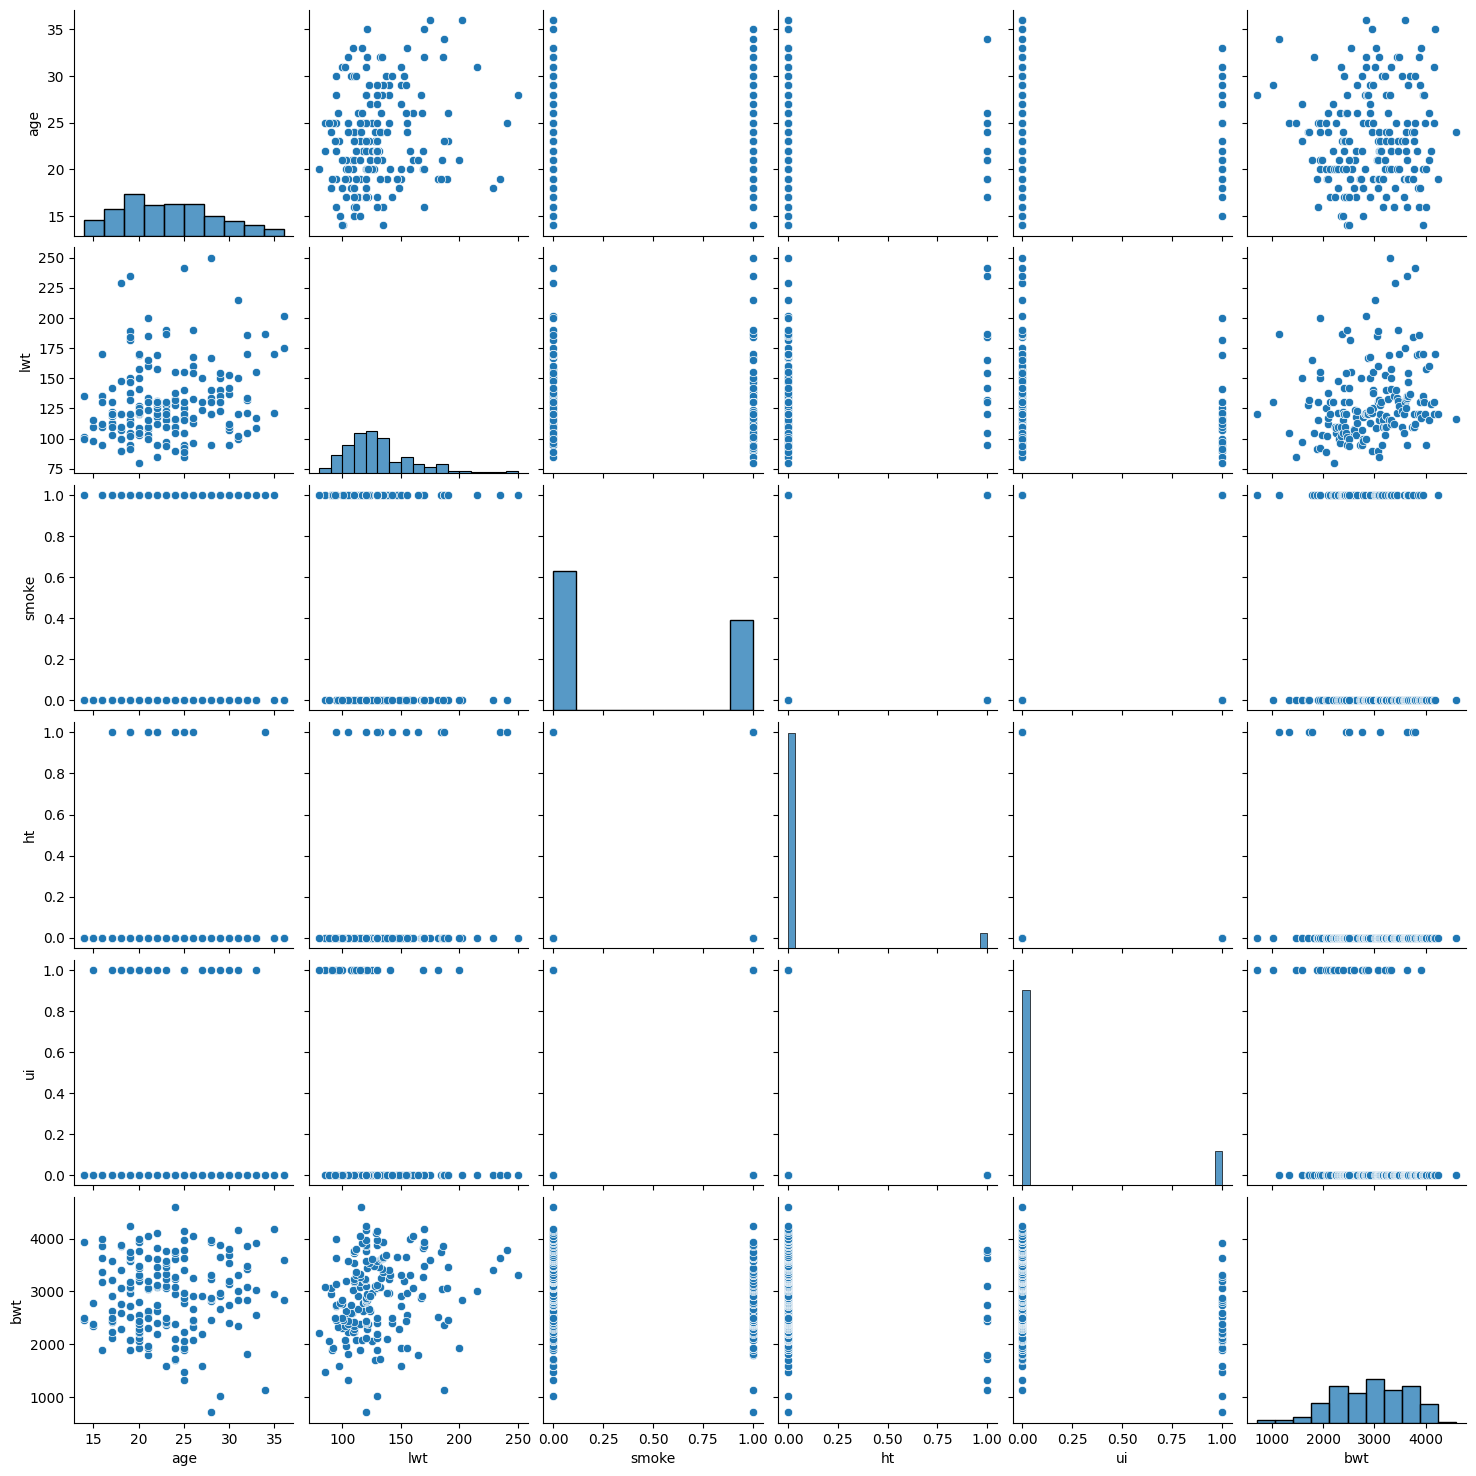

In [42]:
sns.pairplot(df)

In [43]:
model = smf.ols("bwt ~ age + lwt + C(race) + smoke + C(ptl) + ht + ui + C(ftv)", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    bwt   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     4.679
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           1.70e-07
Time:                        16:18:49   Log-Likelihood:                -1469.8
No. Observations:                 188   AIC:                             2972.
Df Residuals:                     172   BIC:                             3023.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2951.4470    325.573      9.065   

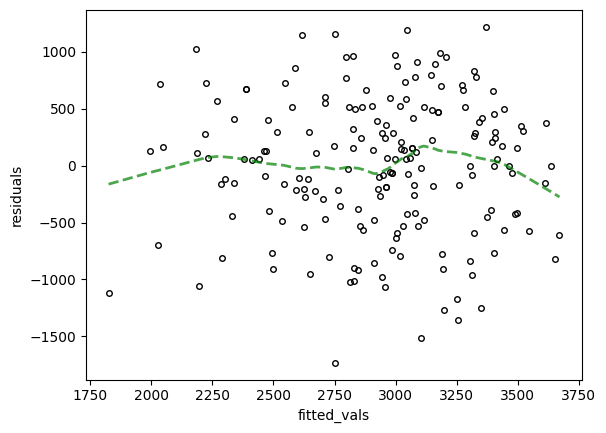

In [44]:
residuals = model.resid
fitted_vals = model.fittedvalues

smooth = lowess(residuals, fitted_vals, frac=0.3) 

plt.plot(fitted_vals, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel('fitted_vals')
plt.ylabel('residuals')
plt.show()

Small correlation is visible between the residuals, seems to be homoscedastic? albeit there is some heteroscedaticity

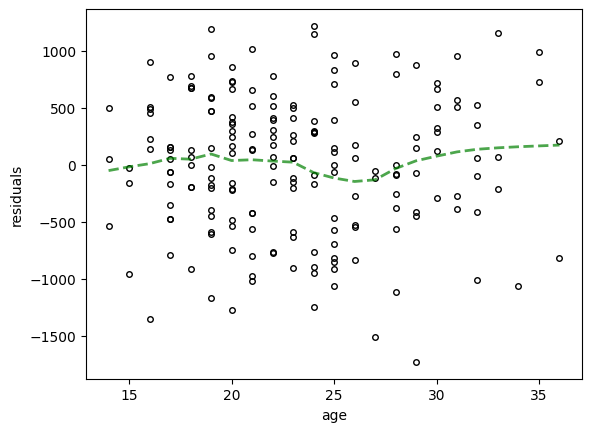

In [45]:
smooth = lowess(residuals, df["age"], frac=0.3) 

plt.plot(df["age"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel('age')
plt.ylabel('residuals')
plt.show()

outliers are affecting the mean of the residuals

In [46]:
# q = df.query("age >= 40")
# print(q)

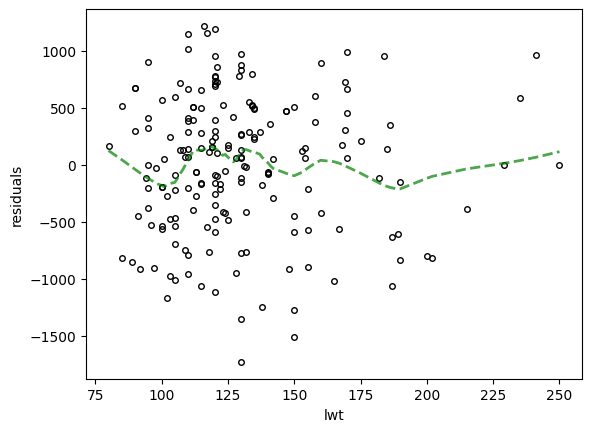

In [47]:
smooth = lowess(residuals, df["lwt"], frac=0.3) 

plt.plot(df["lwt"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel('lwt')
plt.ylabel('residuals')
plt.show()

The noise seems to be fairly homoscedastic, and the assumptions of linear regression seem to hold fairly well. There was an outlier present, and after removal we can see that the residuals are fairly evenly distributed around y = 0 when plotting against the fitted values. \\

We can see that there is slight heteroscedasticity (i.e the $\epsilon$ seems to show some correlation with the variable lwt).

<Axes: title={'center': 'resid'}, xlabel='race'>

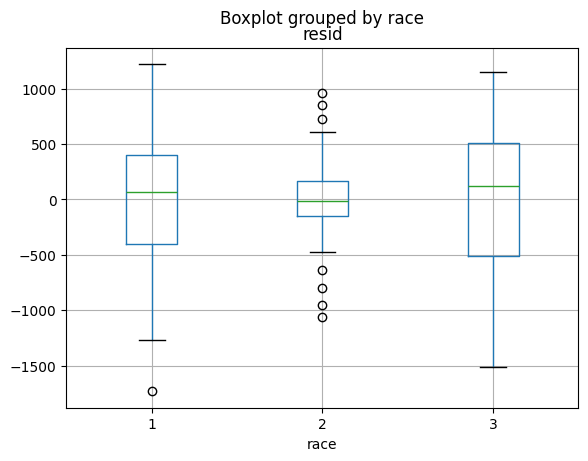

In [49]:
df["resid"] = residuals
df.boxplot(column="resid", by="race")

/var/folders/fk/4xs2tcrs2bb5j8x9qw01540c0000gn/T/ipykernel_13379/677168632.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist(column="resid", by="race", bins=20, figsize=(8,6))


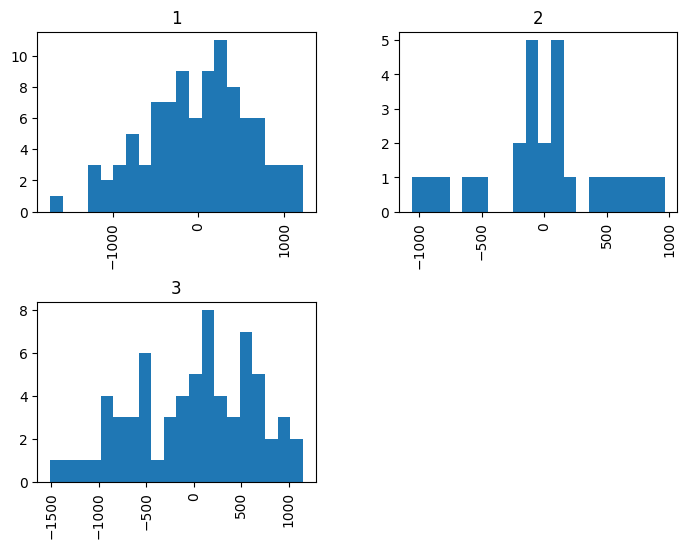

In [55]:
df.hist(column="resid", by="race", bins=20, figsize=(8,6))
plt.show()

<Axes: title={'center': 'resid'}, xlabel='smoke'>

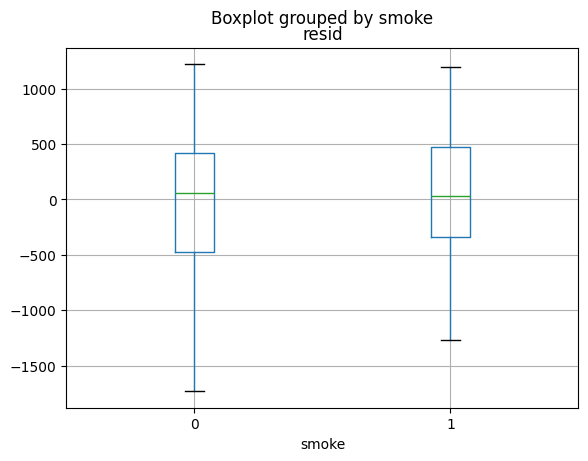

In [56]:
df["resid"] = residuals
df.boxplot(column="resid", by="smoke")

<Axes: title={'center': 'resid'}, xlabel='ftv'>

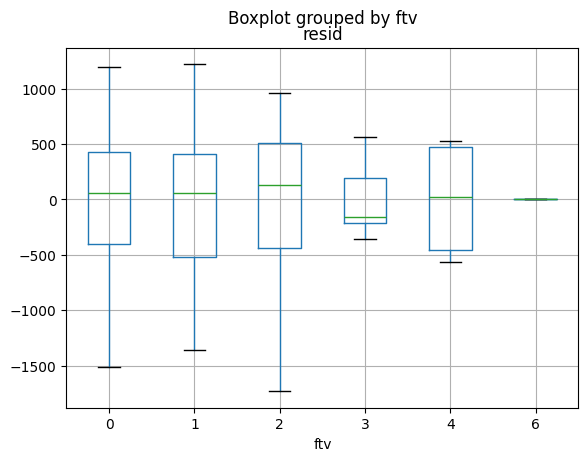

In [57]:
df["resid"] = residuals
df.boxplot(column="resid", by="ftv")

<Axes: title={'center': 'resid'}, xlabel='ptl'>

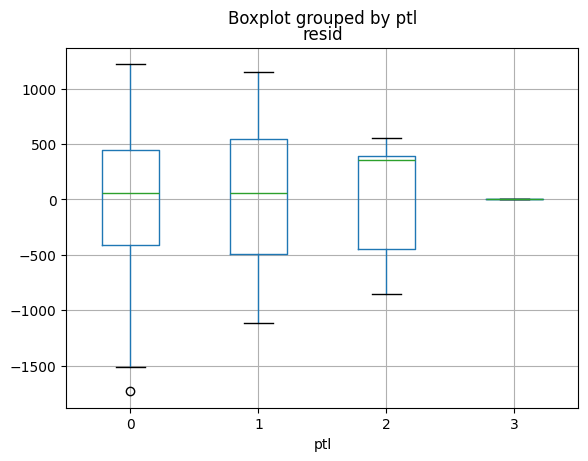

In [59]:
df["resid"] = residuals
df.boxplot(column="resid", by="ptl")

/var/folders/fk/4xs2tcrs2bb5j8x9qw01540c0000gn/T/ipykernel_13379/2910244465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist(column="resid", by="ptl", bins=20, figsize=(8,6))


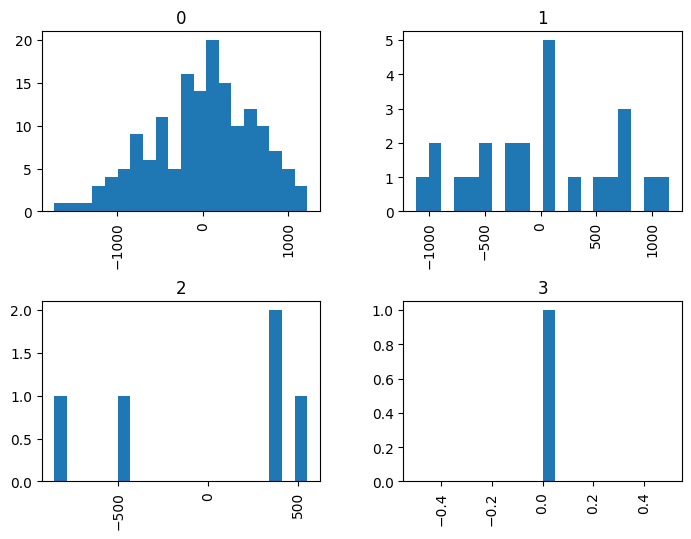

In [60]:
df.hist(column="resid", by="ptl", bins=20, figsize=(8,6))
plt.show()